# Análise de Conformidade Regulatória — APIs Open Finance

**Autora:** Giovanna do Vale Santos

**Objetivo:** Auditar a conformidade de instituições financeiras (IFs) participantes do Open Finance em relação a métricas de Pareamento e Desempenho (P95), identificando padrões de risco e propondo direcionamento de ação corretiva.

> **Nota sobre os dados:** este notebook utiliza um dataset **sintético**, gerado para reproduzir de forma independente os padrões e a metodologia de um case técnico de estudo sobre Open Finance. Nenhum dado real, confidencial ou de terceiros foi utilizado.

## 1. Configuração do Ambiente e Geração dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

np.random.seed(7)


Geramos um dataset sintético simulando 30 dias de chamadas de API para duas instituições financeiras (IF 1 e IF 2) em duas APIs (`Resources` e `Fixed Incomes`), com SLA de 1.500ms e 1.300ms respectivamente.

- **IF 1**: comportamento majoritariamente estável, com picos agudos e isolados de falha (simulando instabilidade de infraestrutura em momentos de pico)
- **IF 2**: comportamento cronicamente abaixo da meta, especialmente na API `Fixed Incomes` (simulando falha estrutural persistente)

In [1]:
dates = pd.date_range("2025-09-01", "2025-09-30", freq="D")
apis = ["Resources", "Fixed Incomes"]
ifs = ["IF 1", "IF 2"]
sla_map = {"Resources": 1500, "Fixed Incomes": 1300}

rows = []
for d in dates:
    day = d.day
    for inst in ifs:
        for api in apis:
            n_calls = np.random.randint(800, 1500)
            sla = sla_map[api]

            if inst == "IF 1":
                pareamento = np.clip(np.random.normal(98, 0.8), 0, 100)
                p95 = max(np.random.normal(sla*0.55, 60), 100)
                if day in [3, 19, 20, 21, 30]:
                    pareamento = np.random.uniform(0, 35)
                    p95 = np.random.uniform(sla*5, sla*10)
            else:
                if api == "Fixed Incomes":
                    pareamento = np.clip(np.random.normal(73, 6), 0, 100)
                    p95 = max(np.random.normal(sla*1.35, 120), 100)
                    if day in [7, 11, 13, 18, 25, 29]:
                        pareamento = np.clip(np.random.normal(97, 1.2), 0, 100)
                        p95 = max(np.random.normal(sla*0.6, 60), 100)
                else:
                    pareamento = np.clip(np.random.normal(95, 2.5), 0, 100)
                    p95 = max(np.random.normal(sla*0.65, 90), 100)
                    if day in [21, 22, 24]:
                        pareamento = np.random.uniform(45, 70)

            paired_calls = int(n_calls * (pareamento/100))

            rows.append({
                "Data": d,
                "Instituicao_Financeira": inst,
                "API": api,
                "total_chamadas": n_calls,
                "paired": paired_calls,
                "Percentual_Pareamento": pareamento,
                "Tempo_Resposta_P95": p95
            })

df = pd.DataFrame(rows)
df.head()


## 2. Cálculo das Métricas

- **Pareamento Diário:** `(chamadas pareadas / total de chamadas) * 100`
- **Desempenho Diário (P95):** percentil 95 do tempo de resposta

In [1]:
df["status_conformidade"] = (df["Tempo_Resposta_P95"] > df["API"].map(sla_map)).astype(int)
df.head()


## 3. Evolução do Pareamento Diário

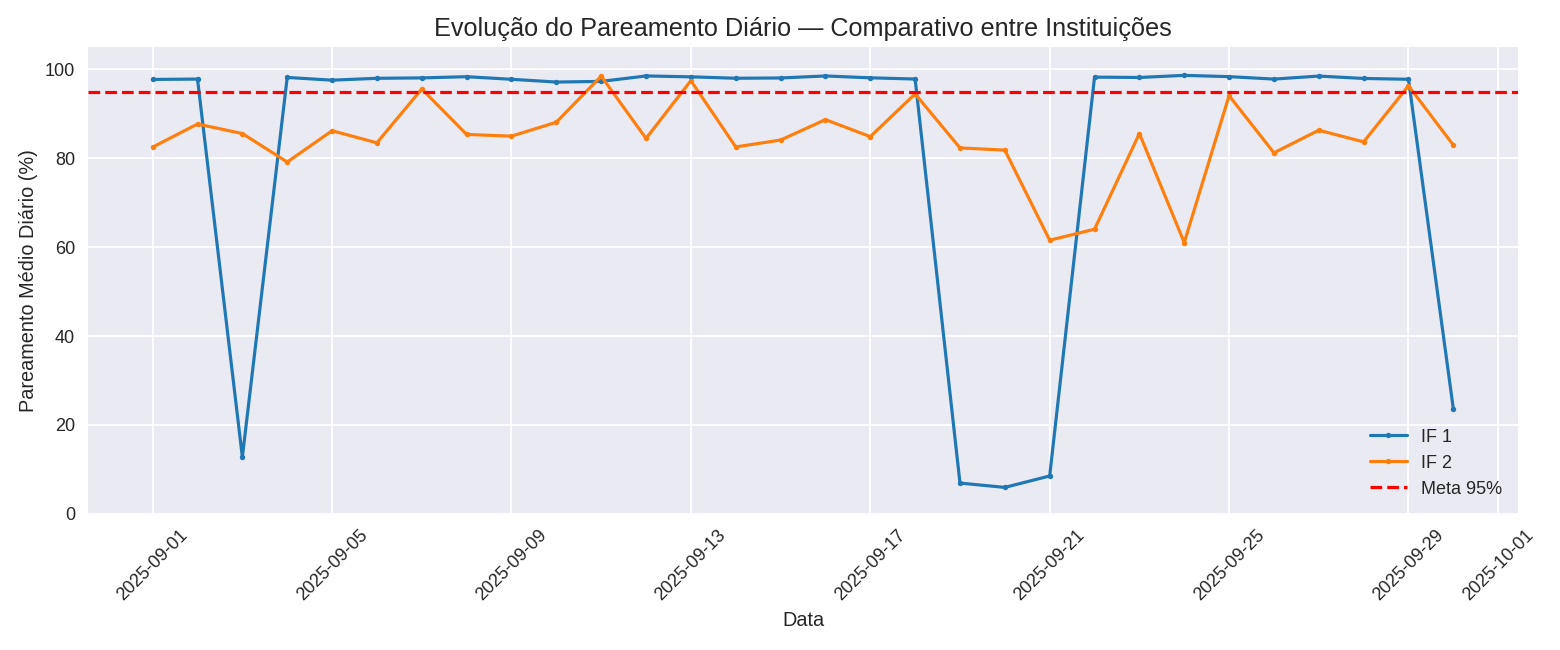

In [1]:
fig, ax = plt.subplots(figsize=(12, 5))
for inst, color in zip(["IF 1", "IF 2"], ["#1f77b4", "#ff7f0e"]):
    sub = df[df["Instituicao_Financeira"] == inst].groupby("Data")["Percentual_Pareamento"].mean()
    ax.plot(sub.index, sub.values, marker="o", markersize=3, label=inst, color=color)
ax.axhline(95, color="red", linestyle="--", label="Meta 95%")
ax.set_title("Evolução do Pareamento Diário — Comparativo entre Instituições", fontsize=14)
ax.set_ylabel("Pareamento Médio Diário (%)")
ax.set_xlabel("Data")
ax.set_ylim(0, 105)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Distribuição de Desempenho (P95) — IF 1

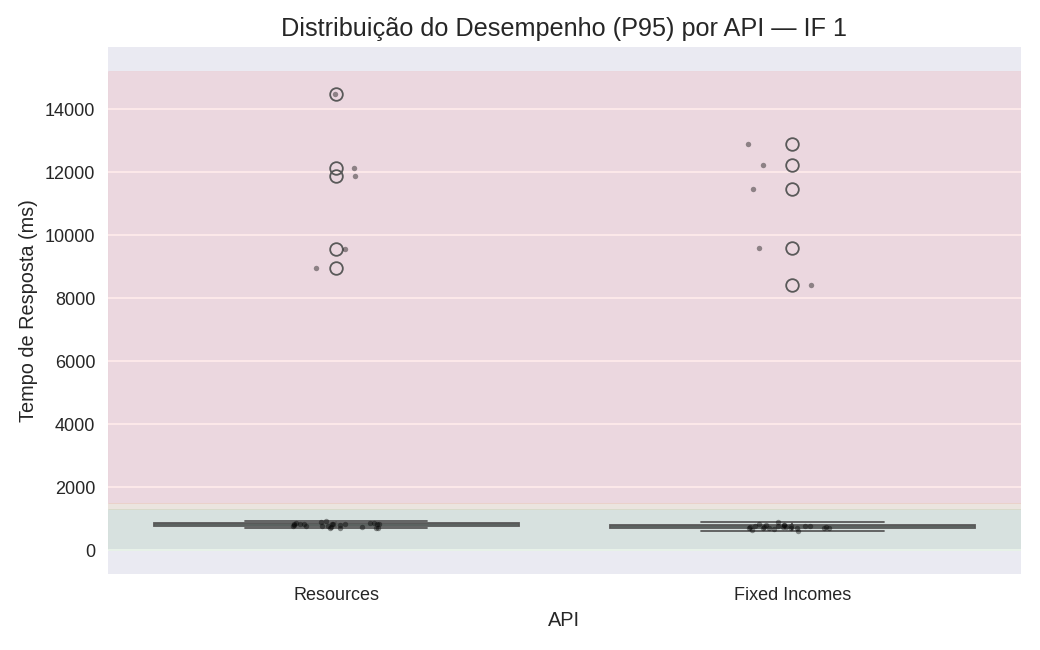

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
sub = df[df["Instituicao_Financeira"] == "IF 1"]
sns.boxplot(data=sub, x="API", y="Tempo_Resposta_P95", ax=ax)
sns.stripplot(data=sub, x="API", y="Tempo_Resposta_P95", ax=ax, color="black", alpha=0.4, size=3)
ax.axhspan(0, 1300, color="green", alpha=0.08)
ax.axhspan(1300, 1500, color="orange", alpha=0.08)
ax.axhspan(1500, ax.get_ylim()[1], color="red", alpha=0.08)
ax.set_title("Distribuição do Desempenho (P95) por API — IF 1", fontsize=14)
ax.set_ylabel("Tempo de Resposta (ms)")
plt.tight_layout()
plt.show()


## 5. Heatmap de Conformidade Diária

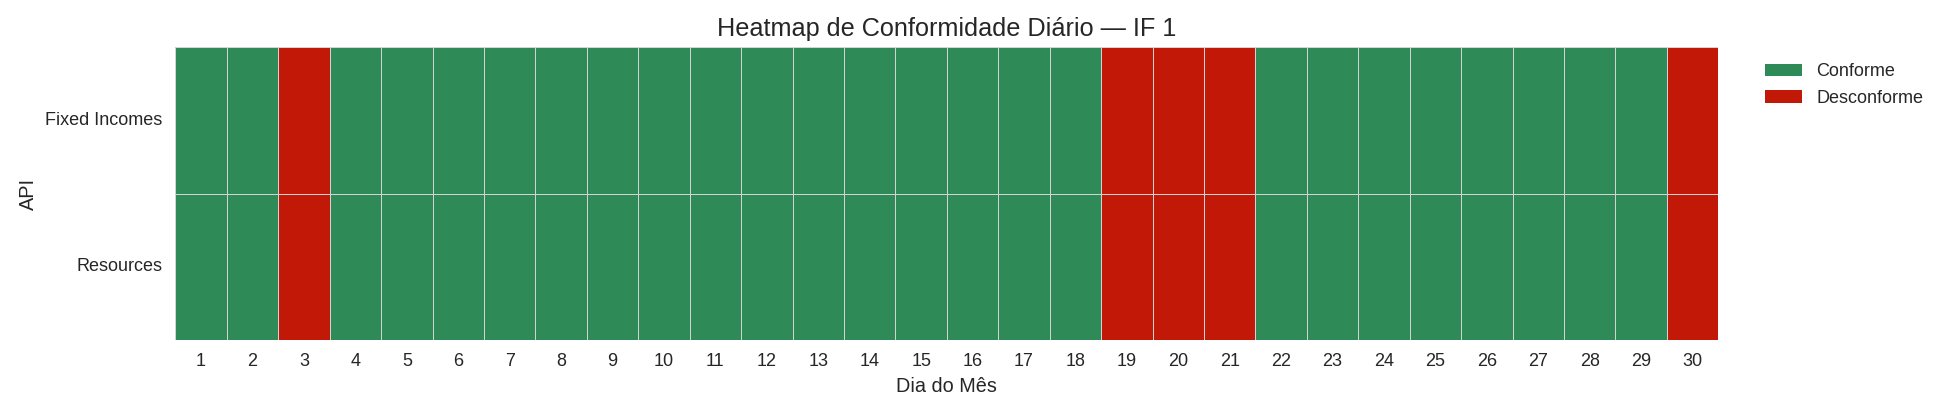

In [1]:
df["dia_mes"] = df["Data"].dt.day
for inst in ["IF 1", "IF 2"]:
    sub = df[df["Instituicao_Financeira"] == inst]
    heat = sub.pivot_table(values="status_conformidade", index="API", columns="dia_mes")
    fig, ax = plt.subplots(figsize=(15, 3.2))
    cmap = ["#2E8B57", "#C21807"]
    sns.heatmap(heat, cmap=cmap, cbar=False, linewidths=.5, linecolor="lightgrey", ax=ax)
    legend_elements = [mpatches.Patch(facecolor=cmap[0], label="Conforme"),
                        mpatches.Patch(facecolor=cmap[1], label="Desconforme")]
    ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(f"Heatmap de Conformidade Diário — {inst}", fontsize=14)
    ax.set_xlabel("Dia do Mês")
    ax.set_ylabel("API")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


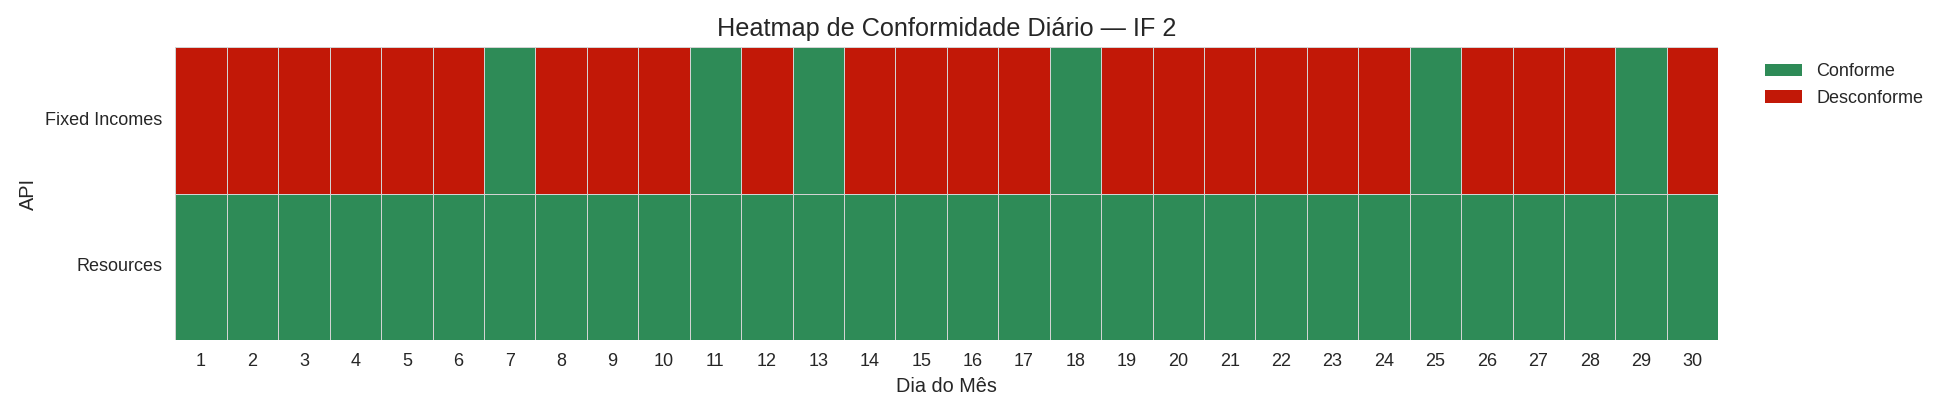

In [1]:
# Heatmap IF 2
# (mesmo código do bloco acima, aplicado a IF 2)

## 6. Quadrante de Performance: Pareamento vs. Desempenho

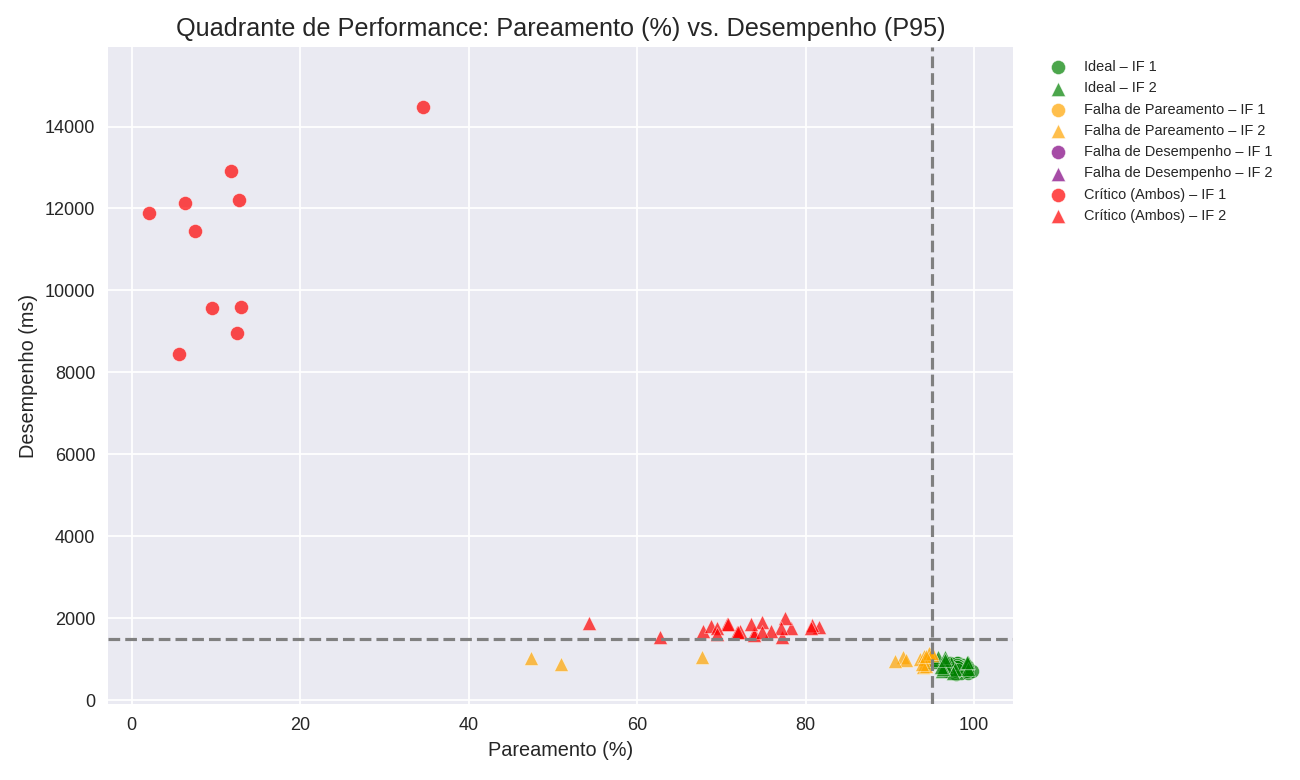

In [1]:
def quadrante(row):
    if row["Percentual_Pareamento"] >= 95 and row["Tempo_Resposta_P95"] < sla_map[row["API"]]:
        return "Ideal"
    elif row["Percentual_Pareamento"] < 95 and row["Tempo_Resposta_P95"] < sla_map[row["API"]]:
        return "Falha de Pareamento"
    elif row["Percentual_Pareamento"] >= 95 and row["Tempo_Resposta_P95"] >= sla_map[row["API"]]:
        return "Falha de Desempenho"
    else:
        return "Crítico (Ambos)"

df["Quadrante"] = df.apply(quadrante, axis=1)
color_map = {"Ideal": "green", "Falha de Pareamento": "orange", "Falha de Desempenho": "purple", "Crítico (Ambos)": "red"}
markers = {"IF 1": "o", "IF 2": "^"}

fig, ax = plt.subplots(figsize=(10, 6))
for q, c in color_map.items():
    for inst, m in markers.items():
        sub = df[(df["Quadrante"] == q) & (df["Instituicao_Financeira"] == inst)]
        ax.scatter(sub["Percentual_Pareamento"], sub["Tempo_Resposta_P95"], c=c, marker=m,
                   label=f"{q} – {inst}", alpha=0.7, edgecolor="white", s=60)
ax.axvline(95, color="gray", linestyle="--")
ax.axhline(1500, color="gray", linestyle="--")
ax.set_title("Quadrante de Performance: Pareamento (%) vs. Desempenho (P95)", fontsize=14)
ax.set_xlabel("Pareamento (%)")
ax.set_ylabel("Desempenho (ms)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 7. Sumário de Insights e Conclusões

**Insight 1 — Risco Agudo (IF 1) comprovado por outliers catastróficos.**
A IF 1, embora geralmente estável (pareamento médio acima de 97% na maior parte dos dias), apresentou dias isolados com P95 acima de **14.000ms** e quedas de pareamento a menos de **10%** — indicando fragilidade de infraestrutura em momentos de pico, não uma falha contínua.

**Insight 2 — Risco Crônico (IF 2) evidenciado pela persistência da falha.**
A API `Fixed Incomes` da IF 2 ficou em desconformidade de SLA por **24 dos 30 dias analisados** — um padrão estrutural, não um evento pontual.

**Insight 3 — A média do sistema mascara o risco real.**
A performance da IF 1 eleva a média consolidada do ecossistema. Isoladamente, o pareamento médio da IF 2 na API `Fixed Incomes` (**≈77,8%**) fica bem abaixo da meta de 95%, revelando o "elo fraco" que compromete a confiança de todo o sistema.

**Conclusão técnica:** os dois perfis de risco pedem respostas diferentes — um **Plano de Mitigação** focado em resiliência de infraestrutura para a IF 1, e um **Plano de Ação Corretiva** mais rigoroso e supervisionado, com acompanhamento próximo, para a IF 2.